# Master Thesis Result Analysis — Core Evaluation Design

This notebook implements the exact evaluation framework designed for the master thesis, focusing exclusively on the 4 core Dependent Variables (DVs):

1. **Output Quality** (Control Agent LLM-as-Judge): 4 dimensions (Accuracy, Completeness, Cohesion, Quality) + Data Traps (caught vs missed) compared against pre-computed ground truth.
2. **Efficiency** (Automatically Tracked): Total token count (per agent, per phase, per run), Turn count (messages per phase), Wall-clock duration.
3. **Worker Satisfaction** (6-Item Likert Survey): Composite mean per worker & team per run (1–5 scale).
4. **Validity & Manipulation Check**: Boss intervention frequency & tone, identical setup across conditions, 5 repetitions per condition.

*Note: Data validation health checks are conducted separately in `02_validation_check.ipynb`, and detailed text communication sentiment analysis is conducted in `03_sentiment_analysis.ipynb`.*


## §0 — Setup & Data Loading

Import core analytical dependencies, set up publication-ready plotting aesthetics, and load the master experiment dataset across all 70 runs (7 leadership styles × 2 task complexities × 5 repetitions).


In [10]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

STYLE_COLORS = {
    'coercive': '#d62728',       # Red
    'authoritative': '#ff7f0e',  # Orange
    'affiliative': '#2ca02c',    # Green
    'democratic': '#1f77b4',     # Blue
    'pacesetting': '#9467bd',    # Purple
    'coaching': '#bcbd22',       # Yellow-green
    'baseline': '#7f7f7f'        # Gray
}

STYLE_ORDER = ['coercive', 'authoritative', 'affiliative', 'democratic', 'pacesetting', 'coaching', 'baseline']

# Hardcoded results path in MAS
RESULTS_DIR = '/Users/hellligkeit/Documents/FS/Masterthesis/MAS/results'

run_dirs = sorted([
    os.path.join(RESULTS_DIR, d)
    for d in os.listdir(RESULTS_DIR)
    if os.path.isdir(os.path.join(RESULTS_DIR, d)) and '_run' in d
])

print(f'Resolved RESULTS_DIR: {os.path.abspath(RESULTS_DIR)}')
print(f'Found {len(run_dirs)} total run directories in results/')

# Load all run artifacts into a single DataFrame
rows = []
for run_dir in run_dirs:
    meta_path = os.path.join(run_dir, 'metadata.json')
    eval_path = os.path.join(run_dir, 'evaluation.json')
    surv_path = os.path.join(run_dir, 'survey_results.json')

    if not all(os.path.exists(p) for p in [meta_path, eval_path, surv_path]):
        continue

    try:
        with open(meta_path, 'r', encoding='utf-8') as f:
            meta = json.load(f)
        with open(eval_path, 'r', encoding='utf-8') as f:
            eval_data = json.load(f)
        with open(surv_path, 'r', encoding='utf-8') as f:
            survey = json.load(f)
    except Exception as e:
        print(f'Skipped {os.path.basename(run_dir)}: {e}')
        continue

    folder = os.path.basename(run_dir)
    parts = folder.split('_')
    style = parts[0] if len(parts) > 0 else meta.get('leadership_style', '')
    task = parts[1] if len(parts) > 1 else meta.get('task_type', '')

    scores = eval_data.get('scores', {})
    workers = survey.get('workers', {})

    def get_score(dim):
        s = scores.get(dim)
        return s.get('score') if isinstance(s, dict) else s

    row = {
        'folder': folder,
        'style': style,
        'task': task,
        'run_id': meta.get('run_id'),
        'total_tokens': meta.get('total_tokens'),
        'duration_seconds': meta.get('duration_seconds'),
        'revision_rounds': meta.get('revision_rounds'),
        'quality_mean': eval_data.get('quality_mean'),
        'overall_quality': eval_data.get('overall_quality'),
        'trap_catch_rate': eval_data.get('trap_catch_rate'),
        'accuracy': get_score('accuracy'),
        'completeness': get_score('completeness'),
        'cohesion': get_score('cohesion'),
        'quality': get_score('quality'),
        'survey_team_mean': survey.get('team_mean'),
        'survey_coder': workers.get('Coder', {}).get('composite_score') if isinstance(workers.get('Coder'), dict) else None,
        'survey_writer': workers.get('Writer', {}).get('composite_score') if isinstance(workers.get('Writer'), dict) else None,
        'survey_reviewer': workers.get('Reviewer', {}).get('composite_score') if isinstance(workers.get('Reviewer'), dict) else None,
    }
    rows.append(row)

df = pd.DataFrame(rows)
if not df.empty:
    df['style'] = pd.Categorical(df['style'], categories=STYLE_ORDER, ordered=True)

print(f'\nLoaded {len(df)} runs into df')
print(df.head())

Resolved RESULTS_DIR: /Users/hellligkeit/Documents/FS/Masterthesis/MAS/results
Found 70 total run directories in results/

Loaded 70 runs into df
                   folder        style  task  run_id  total_tokens  \
0  affiliative_long_run01  affiliative  long       1        169635   
1  affiliative_long_run02  affiliative  long       2        184480   
2  affiliative_long_run03  affiliative  long       3        137326   
3  affiliative_long_run04  affiliative  long       4        150832   
4  affiliative_long_run05  affiliative  long       5        153514   

   duration_seconds  revision_rounds  quality_mean  overall_quality  \
0            253.50                0          2.50              2.0   
1            222.56                1          2.50              2.3   
2            211.74                0          4.25              4.0   
3            210.65                0          2.50              2.0   
4            230.30                0          4.50              4.3   

   tra

## §1 — DV 1: Output Quality (LLM-as-Judge)

Evaluate task deliverable performance scored by the Control Agent across the 4 core dimensions (1–5 scale) and data quality trap catch rates compared against ground truth.


### §1a — Overall Quality Score by Leadership Style

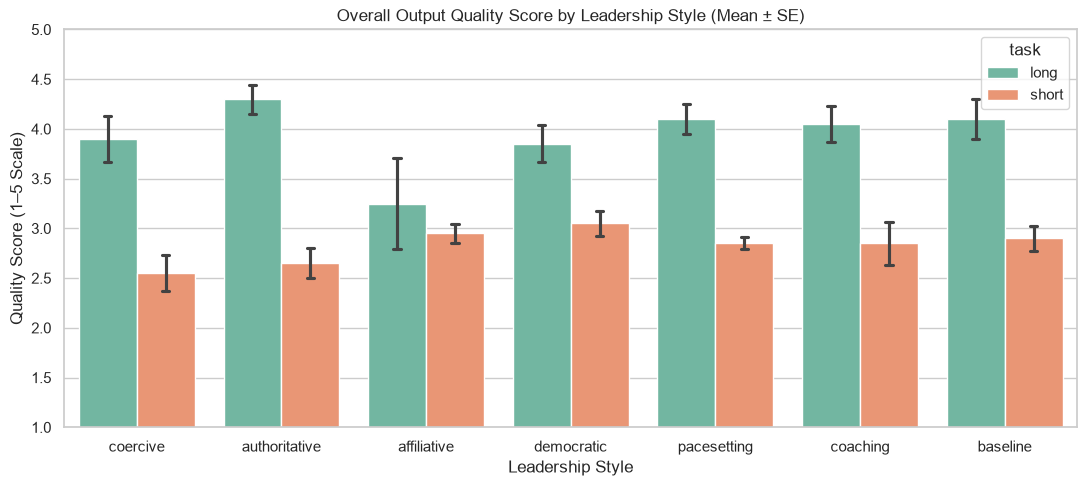

            style   task  mean       std
0        coercive   long  3.90  0.518411
1        coercive  short  2.55  0.410792
2   authoritative   long  4.30  0.325960
3   authoritative  short  2.65  0.335410
4     affiliative   long  3.25  1.030776
5     affiliative  short  2.95  0.209165
6      democratic   long  3.85  0.418330
7      democratic  short  3.05  0.273861
8     pacesetting   long  4.10  0.335410
9     pacesetting  short  2.85  0.136931
10       coaching   long  4.05  0.410792
11       coaching  short  2.85  0.487340
12       baseline   long  4.10  0.454148
13       baseline  short  2.90  0.285044


In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='quality_mean', hue='task', 
    palette='Set2', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax
)
ax.set_title('Overall Output Quality Score by Leadership Style (Mean ± SE)')
ax.set_ylabel('Quality Score (1–5 Scale)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()

# Print summary table
quality_summary = df.groupby(['style', 'task'])['quality_mean'].agg(['mean', 'std']).reset_index()
print(quality_summary)


### §1b — Quality Dimension Breakdown (Accuracy, Completeness, Cohesion, Quality)

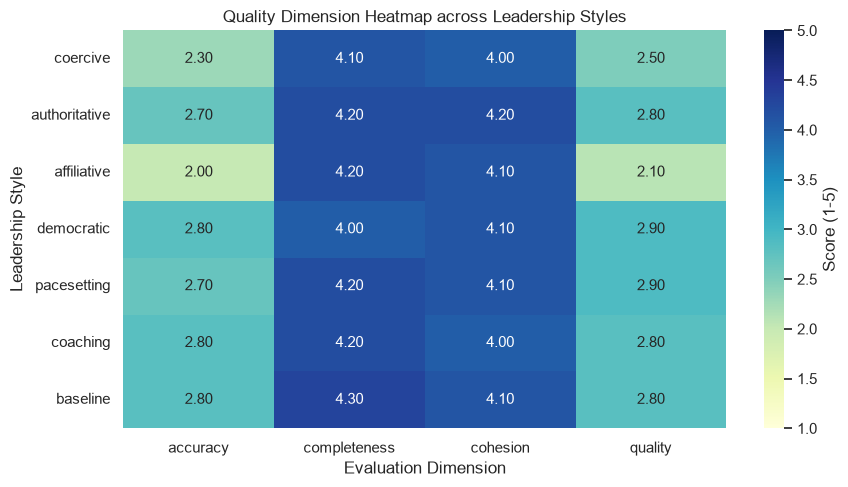

In [12]:
dim_cols = ['accuracy', 'completeness', 'cohesion', 'quality']
dim_means = df.groupby('style')[dim_cols].mean().reindex(STYLE_ORDER)

plt.figure(figsize=(9, 5))
sns.heatmap(dim_means, annot=True, cmap='YlGnBu', fmt='.2f', vmin=1, vmax=5, cbar_kws={'label': 'Score (1-5)'})
plt.title('Quality Dimension Heatmap across Leadership Styles')
plt.xlabel('Evaluation Dimension')
plt.ylabel('Leadership Style')
plt.tight_layout()
plt.show()


### §1c — Data Trap Detection Performance

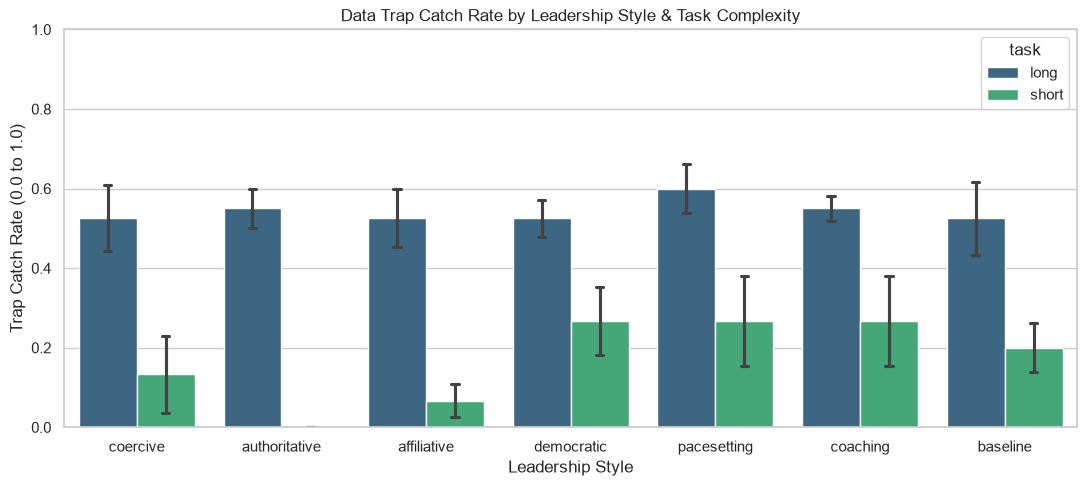

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='trap_catch_rate', hue='task', 
    palette='viridis', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax
)
ax.set_title('Data Trap Catch Rate by Leadership Style & Task Complexity')
ax.set_ylabel('Trap Catch Rate (0.0 to 1.0)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()


## §2 — DV 2: Efficiency (Automatically Tracked)

Analyze computational and temporal resource consumption across conditions:
- Total Token Usage (per agent, per phase, per run)
- Turn Count & Revision Loops
- Wall-Clock Duration (total duration per run)


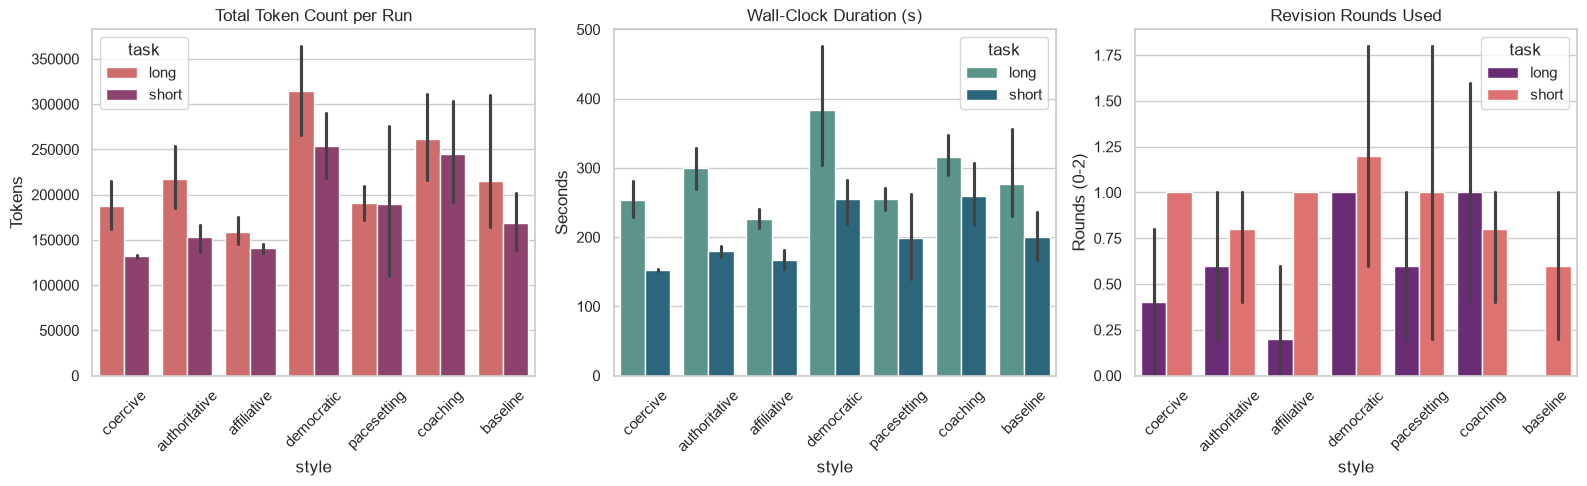

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df, x='style', y='total_tokens', hue='task', palette='flare', order=STYLE_ORDER, ax=axes[0])
axes[0].set_title('Total Token Count per Run')
axes[0].set_ylabel('Tokens')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='style', y='duration_seconds', hue='task', palette='crest', order=STYLE_ORDER, ax=axes[1])
axes[1].set_title('Wall-Clock Duration (s)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='style', y='revision_rounds', hue='task', palette='magma', order=STYLE_ORDER, ax=axes[2])
axes[2].set_title('Revision Rounds Used')
axes[2].set_ylabel('Rounds (0-2)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## §3 — DV 3: Worker Satisfaction (6-Item Likert Survey)

Analyze subjective team satisfaction measured via the post-experiment standardized questionnaire (1–5 scale).


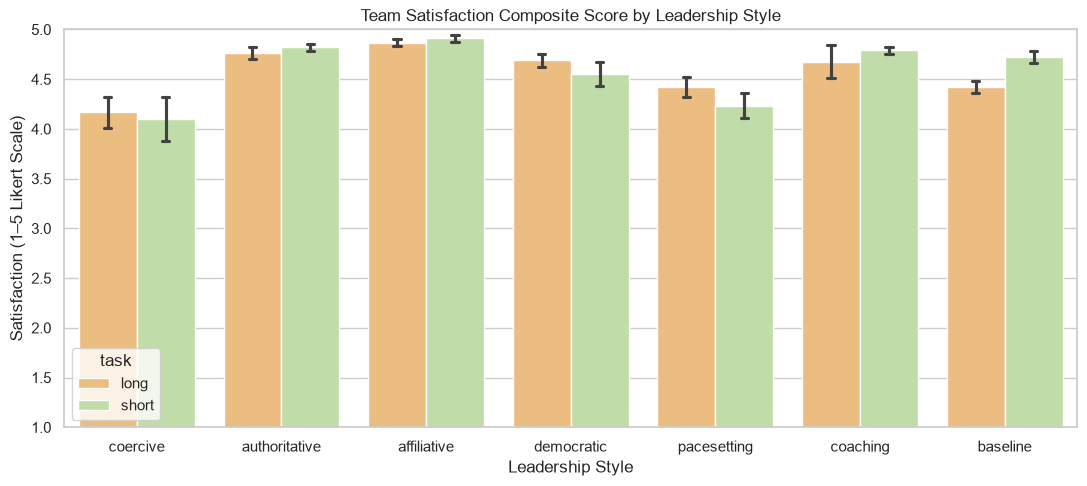

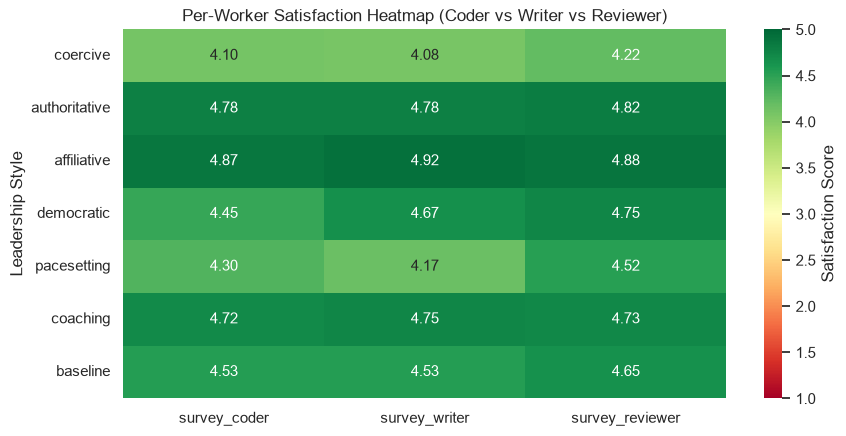

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df, x='style', y='survey_team_mean', hue='task', 
    palette='Spectral', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax
)
ax.set_title('Team Satisfaction Composite Score by Leadership Style')
ax.set_ylabel('Satisfaction (1–5 Likert Scale)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()

# Per worker breakdown
worker_cols = ['survey_coder', 'survey_writer', 'survey_reviewer']
df_worker_sat = df.groupby('style')[worker_cols].mean().reindex(STYLE_ORDER)

plt.figure(figsize=(9, 4.5))
sns.heatmap(df_worker_sat, annot=True, cmap='RdYlGn', fmt='.2f', vmin=1, vmax=5, cbar_kws={'label': 'Satisfaction Score'})
plt.title('Per-Worker Satisfaction Heatmap (Coder vs Writer vs Reviewer)')
plt.ylabel('Leadership Style')
plt.tight_layout()
plt.show()


## §4 — Validity & Manipulation Check

Verify experimental control and check whether leadership style prompts successfully altered Boss behavior (intervention frequency and message count).


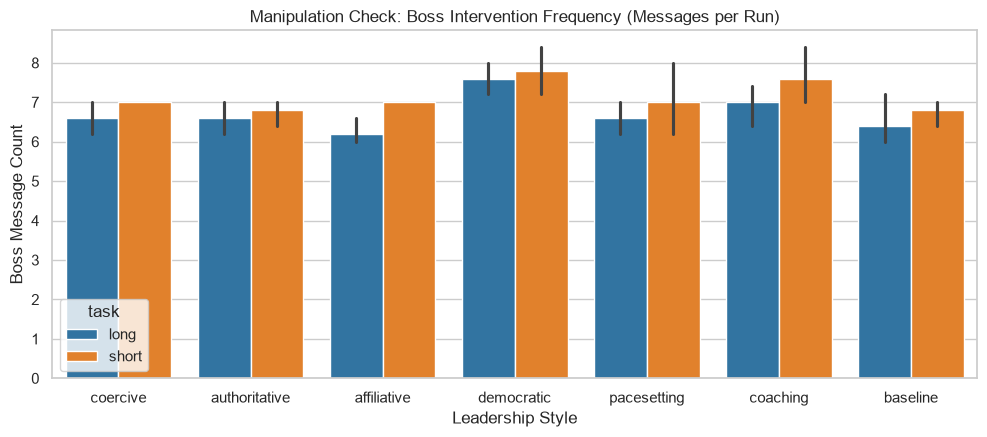

In [16]:
boss_msg_counts = []

for d in run_dirs:
    if not os.path.isdir(d):
        continue
    msg_file = os.path.join(d, 'messages.jsonl')
    b_count = 0
    if os.path.exists(msg_file):
        with open(msg_file, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    if json.loads(line).get('sender') == 'Boss':
                        b_count += 1
                except json.JSONDecodeError:
                    continue
    folder = os.path.basename(d)
    parts = folder.split('_')
    boss_msg_counts.append({
        'folder': folder,
        'style': parts[0] if len(parts) > 0 else '',
        'task': parts[1] if len(parts) > 1 else '',
        'boss_messages': b_count
    })

df_boss = pd.DataFrame(boss_msg_counts)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=df_boss, x='style', y='boss_messages', hue='task', palette='tab10', order=STYLE_ORDER, ax=ax)
ax.set_title('Manipulation Check: Boss Intervention Frequency (Messages per Run)')
ax.set_ylabel('Boss Message Count')
ax.set_xlabel('Leadership Style')
plt.tight_layout()
plt.show()

## §5 — Cross-DV Relationships & Correlations

Examine key trade-offs between Output Quality, Efficiency (Tokens/Duration), and Worker Satisfaction.


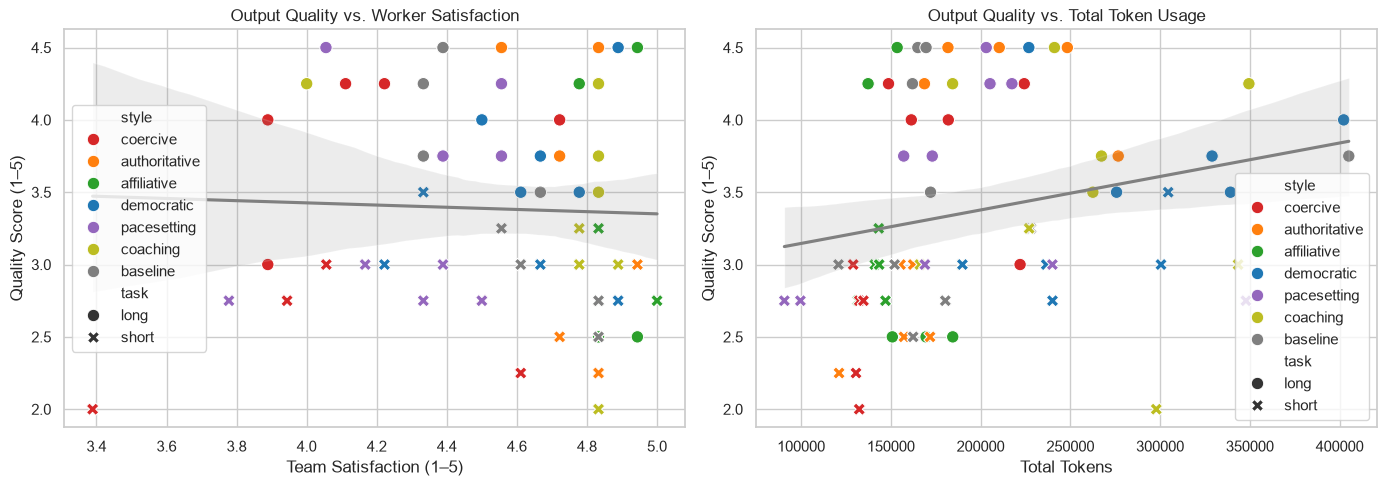

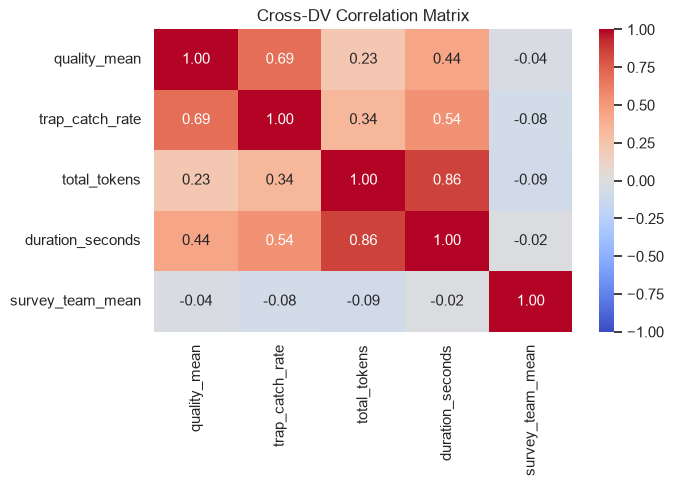

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality vs Satisfaction
sns.scatterplot(data=df, x='survey_team_mean', y='quality_mean', hue='style', style='task', s=80, palette=STYLE_COLORS, ax=axes[0])
sns.regplot(data=df, x='survey_team_mean', y='quality_mean', scatter=False, ax=axes[0], color='gray')
axes[0].set_title('Output Quality vs. Worker Satisfaction')
axes[0].set_xlabel('Team Satisfaction (1–5)')
axes[0].set_ylabel('Quality Score (1–5)')

# Quality vs Tokens
sns.scatterplot(data=df, x='total_tokens', y='quality_mean', hue='style', style='task', s=80, palette=STYLE_COLORS, ax=axes[1])
sns.regplot(data=df, x='total_tokens', y='quality_mean', scatter=False, ax=axes[1], color='gray')
axes[1].set_title('Output Quality vs. Total Token Usage')
axes[1].set_xlabel('Total Tokens')
axes[1].set_ylabel('Quality Score (1–5)')

plt.tight_layout()
plt.show()

# Correlation Matrix
corr_cols = ['quality_mean', 'trap_catch_rate', 'total_tokens', 'duration_seconds', 'survey_team_mean']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Cross-DV Correlation Matrix')
plt.tight_layout()
plt.show()


## §6 — Non-Parametric Statistical Testing

Perform Kruskal-Wallis non-parametric tests across the 7 leadership styles for Output Quality, Efficiency, and Worker Satisfaction, followed by pairwise Mann-Whitney U tests for significant metrics.


In [18]:
stats_results = []

metrics_to_test = {
    'Output Quality': 'quality_mean',
    'Trap Catch Rate': 'trap_catch_rate',
    'Total Tokens': 'total_tokens',
    'Duration (s)': 'duration_seconds',
    'Team Satisfaction': 'survey_team_mean'
}

for name, col in metrics_to_test.items():
    for task_type in sorted(df['task'].dropna().unique()):
        df_task = df[df['task'] == task_type]
        groups = [group[col].dropna().values for _, group in df_task.groupby('style')]
        if len(groups) > 1 and all(len(g) > 0 for g in groups):
            H, p = stats.kruskal(*groups)
            stats_results.append({
                'Metric': name,
                'Task': task_type,
                'H-Statistic': round(H, 3),
                'p-value': round(p, 4),
                'Significant (p < .05)': 'Yes' if p < 0.05 else 'No'
            })

df_stats = pd.DataFrame(stats_results)
print('=' * 60)
print('   KRUSKAL-WALLIS TEST RESULTS BY TASK TYPE')
print('=' * 60)
print(df_stats.to_string(index=False))

   KRUSKAL-WALLIS TEST RESULTS BY TASK TYPE
           Metric  Task  H-Statistic  p-value Significant (p < .05)
   Output Quality  long        5.864   0.4385                    No
   Output Quality short        7.436   0.2824                    No
  Trap Catch Rate  long        0.717   0.9941                    No
  Trap Catch Rate short       10.134   0.1191                    No
     Total Tokens  long       17.375   0.0080                   Yes
     Total Tokens short       17.802   0.0067                   Yes
     Duration (s)  long       17.570   0.0074                   Yes
     Duration (s) short       19.097   0.0040                   Yes
Team Satisfaction  long       19.899   0.0029                   Yes
Team Satisfaction short       23.736   0.0006                   Yes
